## Data Visualization Critique & Redesign Notebook

This notebook identifies two infamous, real-world data visualization blunders from major media outlets, details their specific design flaws, and recreates them using Python (Matplotlib and Seaborn) with best practices applied.

## Chart 1: The Fox News 178% Backed Primary Pie Chart (2012)
### 1. Original Image Embed

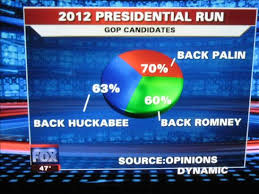

### 2. Documented Design Flaws
Mathematical Impossibility (Violates Part-to-Whole Rule): Pie charts are strictly reserved for displaying components that sum up to exactly 100%. This chart aggregates multiple-choice survey responses, yielding a total of 178%, distorting the visual reality.

Misleading Visual Area: Because it uses a circular layout, slices overlap conceptually but are drawn sequentially, making it look like Sarah Palin owns nearly half of a single, finite pool of voters, which is false.

Absence of Contextual Labels: The chart completely fails to note anywhere on its face that voters were allowed to choose multiple candidates, an omission that transforms a survey error into a misleading political graphic.

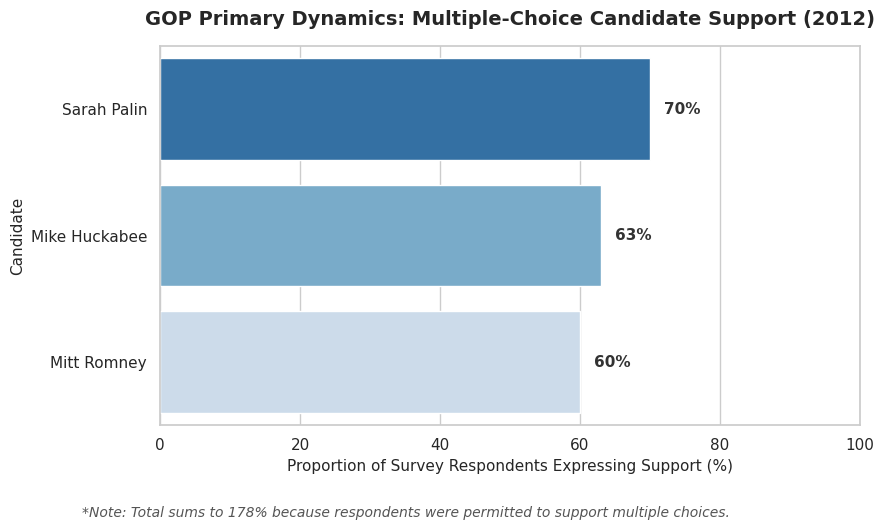

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_gop = {
    'Candidate': ['Sarah Palin', 'Mike Huckabee', 'Mitt Romney'],
    'Support_Percentage': [70, 63, 60]
}
df_gop = pd.DataFrame(data_gop)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x='Support_Percentage', 
    y='Candidate', 
    data=df_gop, 
    palette='Blues_r',
    hue='Candidate',
    legend=False
)

plt.title('GOP Primary Dynamics: Multiple-Choice Candidate Support (2012)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Proportion of Survey Respondents Expressing Support (%)', fontsize=11)
plt.ylabel('Candidate', fontsize=11)
plt.xlim(0, 100)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 2, p.get_y() + p.get_height()/2, f'{int(width)}%', 
            ha='left', va='center', fontsize=11, weight='bold', color='#333333')

plt.figtext(0.1, -0.05, "*Note: Total sums to 178% because respondents were permitted to support multiple choices.", 
            fontsize=10, style='italic', color='#555555')

plt.tight_layout()
plt.show()

### 4. Before/After Comparison
The "Before" Visual: Forced non-exclusive data categories into a closed 360-degree circle, creating an optical illusion that implied a candidate held a super-majority of an exclusive pie.

The "After" Redesign: Converted the visualization into a Horizontal Bar Chart. Because bars track along independent lines anchored to a baseline, the human eye inherently processes them as separate entities rather than components of a fixed 100% whole. Added an explicit tracking baseline up to 100% and an explanatory subtitle to ensure absolute clarity.

## Chart 2: The Reuters Inverted "Gun Deaths in Florida" Line Chart (2014)
### 2.1 Original Image Embed

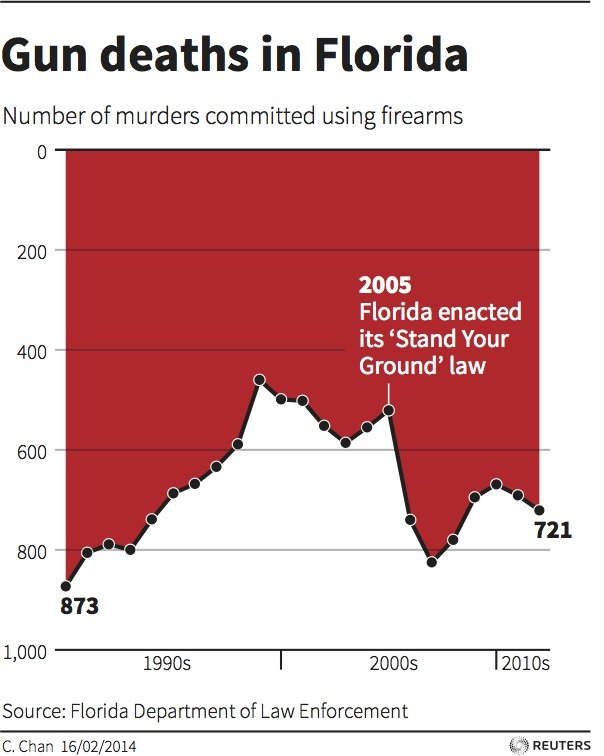

### 2.2 Documented Design FlawsInverted Vertical Axis ($Y$-axis): 
The $Y$-axis places 0 at the very top of the graphic and the highest number (800) at the baseline. This tricks standard human visual processing into reading a massive spike in deaths as a downward slope.

Deceptive Color/Shading Mask: The area under the curve is filled with dark crimson bleeding from the top down, forcing the viewer to instinctually view the white space below as a "mountain" peak, completely hiding the tragedy in the data.

Misleading Baseline Labeling: The timeline marker tracking the passage of the "Stand Your Ground" law sits directly above an escalating vector, yet the visual hierarchy makes it appear as though the law caused deaths to bottom out.

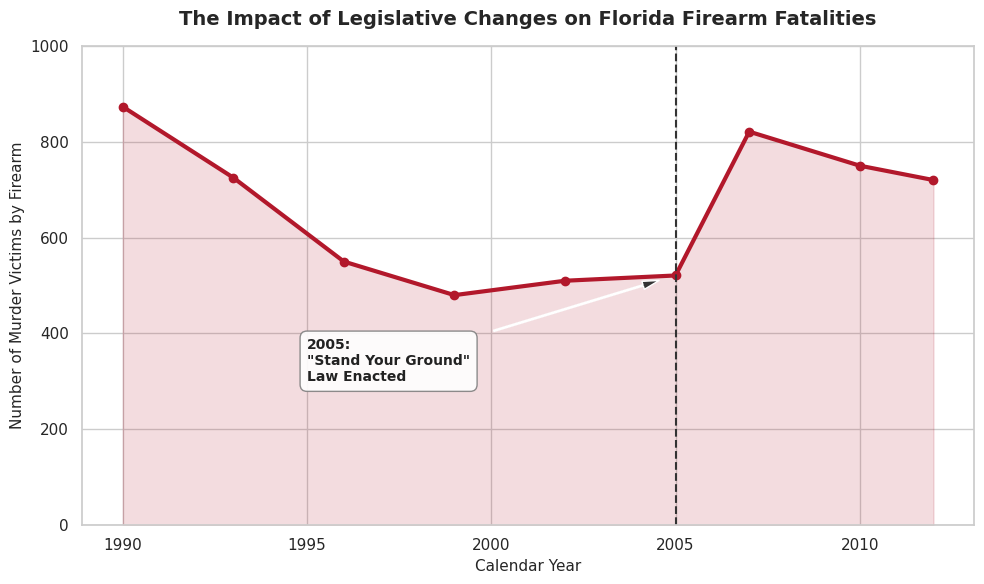

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_violence = {
    'Year': [1990, 1993, 1996, 1999, 2002, 2005, 2007, 2010, 2012],
    'Gun_Deaths': [873, 725, 550, 480, 510, 521, 821, 750, 720]
}
df_violence = pd.DataFrame(data_violence)

plt.figure(figsize=(10, 6))

plt.plot(df_violence['Year'], df_violence['Gun_Deaths'], 
         marker='o', color='#b2182b', linewidth=3, label='Annual Gun Deaths')

plt.fill_between(df_violence['Year'], df_violence['Gun_Deaths'], color='#b2182b', alpha=0.15)

plt.ylim(0, 1000)
plt.title('The Impact of Legislative Changes on Florida Firearm Fatalities', fontsize=14, weight='bold', pad=15)
plt.xlabel('Calendar Year', fontsize=11)
plt.ylabel('Number of Murder Victims by Firearm', fontsize=11)

plt.axvline(x=2005, color='#333333', linestyle='--', linewidth=1.5)
plt.annotate('2005:\n"Stand Your Ground"\nLaw Enacted', 
             xy=(2005, 521), 
             xytext=(1995, 300),
             arrowprops=dict(facecolor='#333333', shrink=0.08, width=1, headwidth=6),
             fontsize=10, weight='bold', color='#222222', bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9))

plt.tight_layout()
plt.show()

### 2.4 Before/After Comparison

The "Before" Visual: Manipulated systemic chart physics by running the metric scale backwards. The audience sub-consciously processed a post-2005 death explosion as a massive victory/drop in gun violence.

The "After" Redesign: Flipped the $Y$-axis back to its natural mathematical state (0 anchored at the bottom baseline). The visual area fill now tracks up from zero, immediately laying bare the real story: gun deaths skyrocketed in Florida following the 2005 legislative shift.